In [626]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor

pd.options.mode.chained_assignment = None
data = pd.read_csv('swiss_job_offers.csv')

data = data.drop('MaternityLeaveWeeks', axis=1)
data = data.drop('PaternityLeaveWeeks', axis=1)
data = data.drop('CitySize', axis=1)
data = data.drop('Perks', axis=1)
data = data.drop('MinYearsExperience', axis=1)
data['Languages'] = data['Languages'].fillna('unknown')



#data[data.isna().any(axis=1)]
data

,Diploma,Role,Contract,Industry,Canton,CompanySize,Languages,Holidays,WorkloadPercent,SalaryCHF
0,PhD,Manager,Permanent,Education,ZH,Small (50-200),"English, German",25,100,314500
1,Bachelor,Senior,Permanent,Manufacturing,SO,Large (1000+),"French, German",25,100,143600
2,Bachelor,Mid-level,Permanent,Manufacturing,SO,Medium (200-1000),"English, German",25,100,84300
3,Bachelor,Junior,1 year,Healthcare,BE,Small (50-200),"English, German",25,90,45300
4,PhD,Mid-level,Permanent,Finance,FR,Medium (200-1000),"French, German",26,90,130200
...,...,...,...,...,...,...,...,...,...,...
495,Master,Intern,6 months,Hospitality,SO,Startup (<50),"French, English, German",28,60,25000
496,Apprenticeship,Junior,Permanent,Finance,ZH,Medium (200-1000),"French, German",25,80,67600
497,Bachelor,Senior,Permanent,Manufacturing,TG,Large (1000+),German,24,80,122200
498,Bachelor,Mid-level,2 years,Consulting,ZH,Medium (200-1000),German,28,90,103000


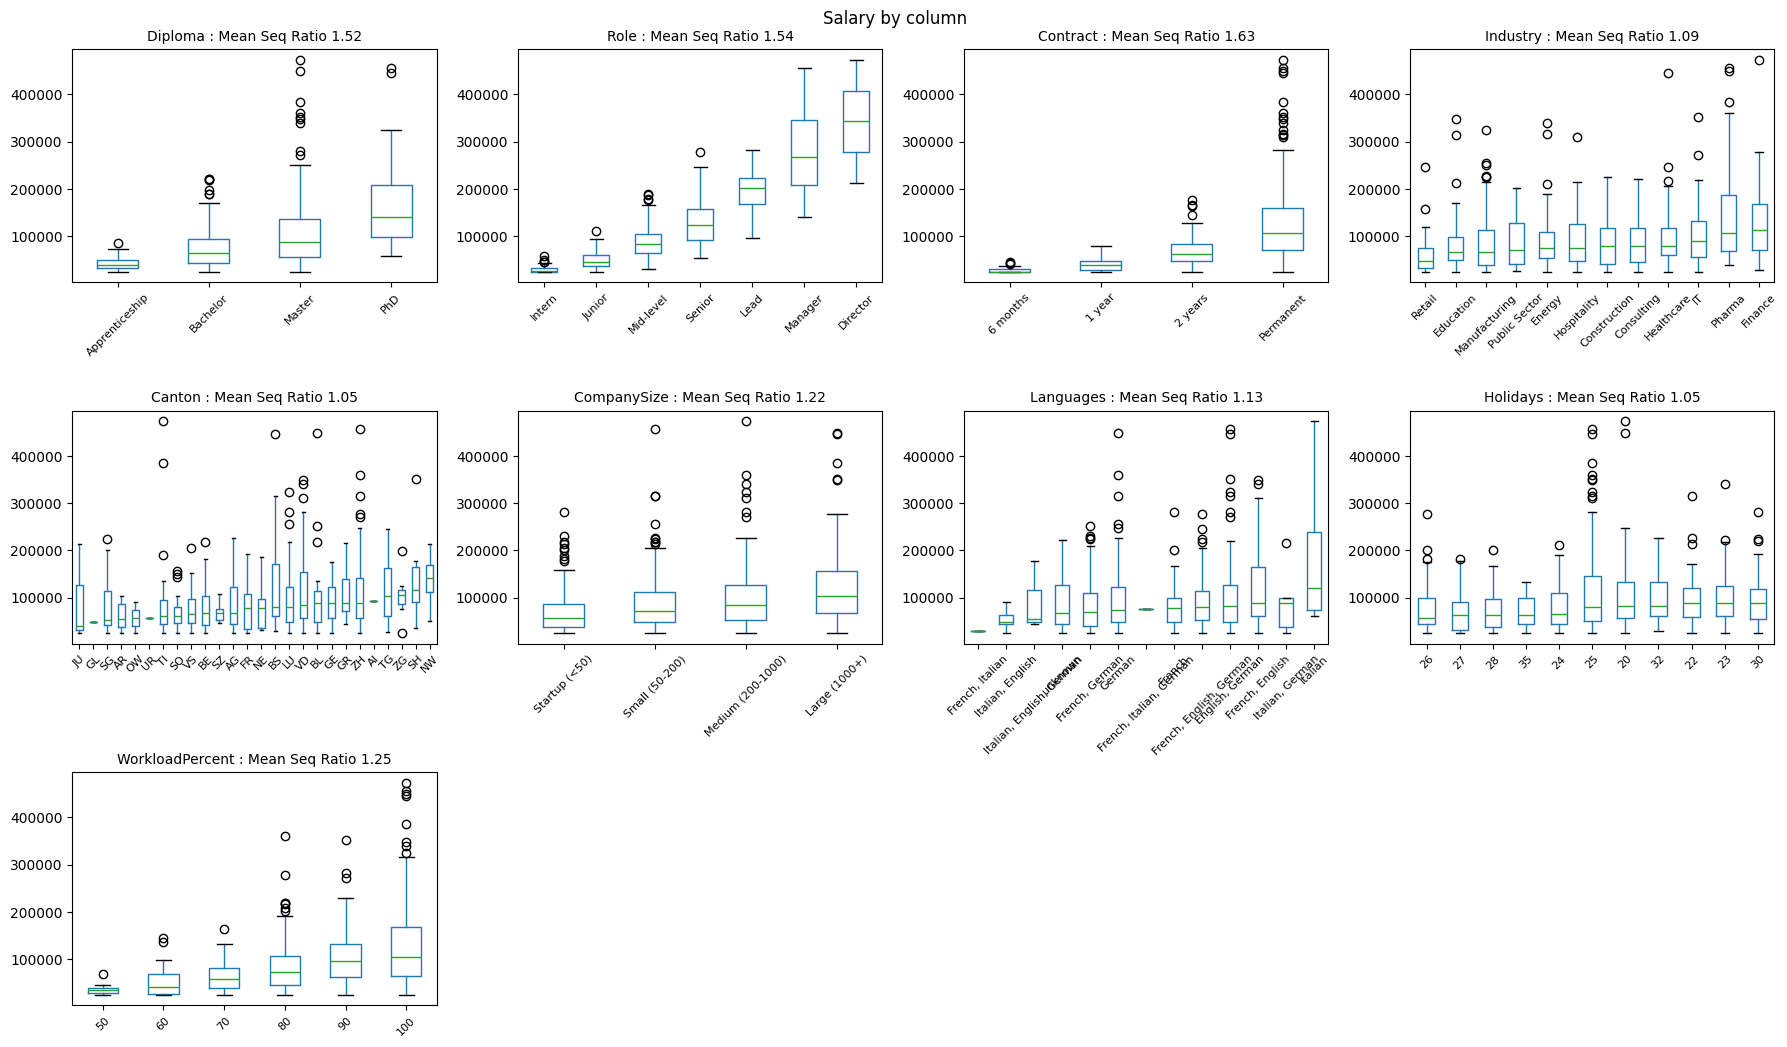

{'Diploma': np.float64(1.52), 'Role': np.float64(1.54), 'Contract': np.float64(1.63)}


In [627]:

col_ratios = {}

cols = data.columns.drop("SalaryCHF")
fig, axes = plt.subplots(4, 4, figsize=(18, 14))

for ax, col in zip(axes.ravel(), cols):
    sorted_medians = data.groupby(col)["SalaryCHF"].median().sort_values()
    order = sorted_medians.index

    sequential_ratio = sorted_medians / sorted_medians.shift(1)

    mean_sequential_ratio = sequential_ratio.mean()

    #print(f"Sequential ratio for {col}: {sequential_ratio}")
    #print(f"-Mean sequential ratio : {mean_sequential_ratio}-")
    
    
    tmp = data.assign(**{col: pd.Categorical(data[col], order, ordered=True)})
    tmp.boxplot(column="SalaryCHF", by=col, ax=ax, grid=False)
    ax.set_title(f"{col} : Mean Seq Ratio {mean_sequential_ratio.round(2)}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    

for ax in axes.ravel()[len(cols):]:
    ax.set_visible(False)

fig.suptitle("Salary by column")
plt.tight_layout()
plt.show()
#ax.set_title('Salary Distribution')

THRESHOLD_RATIO = 1.4

for col in cols:
    sorted_medians = data.groupby(col)["SalaryCHF"].median().sort_values()
    sequential_ratio = sorted_medians / sorted_medians.shift(1)
    mean_sequential_ratio = sequential_ratio.mean()

    if mean_sequential_ratio > THRESHOLD_RATIO:
        col_ratios[col] = mean_sequential_ratio.round(2)

print(col_ratios)



In [628]:
data['Diploma'].value_counts()
data['Role'].value_counts()
#data['MinYearsExperience'].value_counts()

Role
Mid-level    172
Junior       134
Senior        94
Intern        46
Manager       26
Lead          26
Director       2
Name: count, dtype: int64

In [629]:
#PUT ALL THE SALARY AT A 100% WORKLOAD
data["SalaryCHF"] = (data["SalaryCHF"] / data["WorkloadPercent"] * 100).round()

data = data.drop('WorkloadPercent', axis=1)

In [630]:
"""

bounds = data["MinYearsExperience"].str.extract(r"(\d+)\s*to\s*(\d+)").astype(float)
data["ExpMin"] = bounds[0]
data["ExpMax"] = bounds[1]
data = data.drop(columns="MinYearsExperience")

data
"""

<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\gaeta\AppData\Local\Temp\ipykernel_7776\2378055736.py:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  bounds = data["MinYearsExperience"].str.extract(r"(\d+)\s*to\s*(\d+)").astype(float)


'\n\nbounds = data["MinYearsExperience"].str.extract(r"(\\d+)\\s*to\\s*(\\d+)").astype(float)\ndata["ExpMin"] = bounds[0]\ndata["ExpMax"] = bounds[1]\ndata = data.drop(columns="MinYearsExperience")\n\ndata\n'

In [631]:
LANGUAGES = ["French", "German", "English", "Italian"]
for lang in LANGUAGES:
    data[f"Lang_{lang}"] = data["Languages"].str.contains(lang).astype(int)
data["LangCount"] = data[[f"Lang_{l}" for l in LANGUAGES]].sum(axis=1)
data = data.drop(columns="Languages")

data

,Diploma,Role,Contract,Industry,Canton,CompanySize,Holidays,SalaryCHF,Lang_French,Lang_German,Lang_English,Lang_Italian,LangCount
0,PhD,Manager,Permanent,Education,ZH,Small (50-200),25,314500.0,0,1,1,0,2
1,Bachelor,Senior,Permanent,Manufacturing,SO,Large (1000+),25,143600.0,1,1,0,0,2
2,Bachelor,Mid-level,Permanent,Manufacturing,SO,Medium (200-1000),25,84300.0,0,1,1,0,2
3,Bachelor,Junior,1 year,Healthcare,BE,Small (50-200),25,50333.0,0,1,1,0,2
4,PhD,Mid-level,Permanent,Finance,FR,Medium (200-1000),26,144667.0,1,1,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Master,Intern,6 months,Hospitality,SO,Startup (<50),28,41667.0,1,1,1,0,3
496,Apprenticeship,Junior,Permanent,Finance,ZH,Medium (200-1000),25,84500.0,1,1,0,0,2
497,Bachelor,Senior,Permanent,Manufacturing,TG,Large (1000+),24,152750.0,0,1,0,0,1
498,Bachelor,Mid-level,2 years,Consulting,ZH,Medium (200-1000),28,114444.0,0,1,0,0,1


In [632]:
DIPLOMA_ORDER = ["None", "Apprenticeship", "Bachelor", "Master", "PhD"]
SIZE_ORDER = ["Startup (<50)", "Small (50-200)", "Medium (200-1000)", "Large (1000+)"]
 
print("Diploma :", sorted(data["Diploma"].unique()))
print("Size :", sorted(data["CompanySize"].unique()))
 
data["DiplomaLevel"] = data["Diploma"].map(
    {name: i for i, name in enumerate(DIPLOMA_ORDER)}
)
data["CompanySizeLevel"] = data["CompanySize"].map(
    {name: i for i, name in enumerate(SIZE_ORDER)}
)
data = data.drop(columns=["Diploma", "CompanySize"])
data

Diploma : ['Apprenticeship', 'Bachelor', 'Master', 'PhD']
Size : ['Large (1000+)', 'Medium (200-1000)', 'Small (50-200)', 'Startup (<50)']


,Role,Contract,Industry,Canton,Holidays,SalaryCHF,Lang_French,Lang_German,Lang_English,Lang_Italian,LangCount,DiplomaLevel,CompanySizeLevel
0,Manager,Permanent,Education,ZH,25,314500.0,0,1,1,0,2,4,1
1,Senior,Permanent,Manufacturing,SO,25,143600.0,1,1,0,0,2,2,3
2,Mid-level,Permanent,Manufacturing,SO,25,84300.0,0,1,1,0,2,2,2
3,Junior,1 year,Healthcare,BE,25,50333.0,0,1,1,0,2,2,1
4,Mid-level,Permanent,Finance,FR,26,144667.0,1,1,0,0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Intern,6 months,Hospitality,SO,28,41667.0,1,1,1,0,3,3,0
496,Junior,Permanent,Finance,ZH,25,84500.0,1,1,0,0,2,1,2
497,Senior,Permanent,Manufacturing,TG,24,152750.0,0,1,0,0,1,2,3
498,Mid-level,2 years,Consulting,ZH,28,114444.0,0,1,0,0,1,2,2


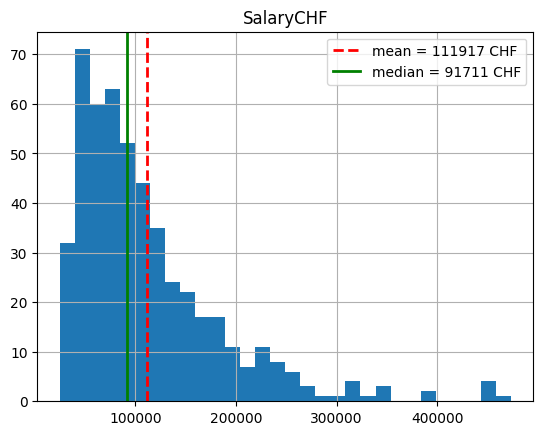

In [633]:
histo = data['SalaryCHF'].hist(bins=30)
mean = data['SalaryCHF'].mean()
median = data['SalaryCHF'].median()
histo.axvline(
    x=mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"mean = {int(mean)} CHF"
)
histo.axvline(
    x=median,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"median = {int(median)} CHF"
)
plt.title('SalaryCHF')
plt.legend()
plt.show()

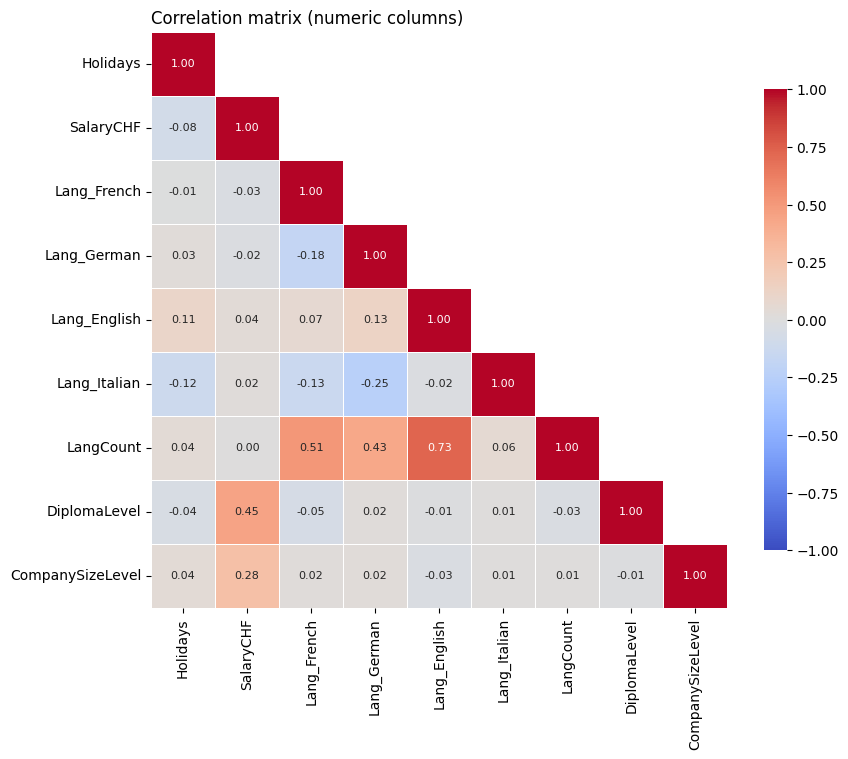

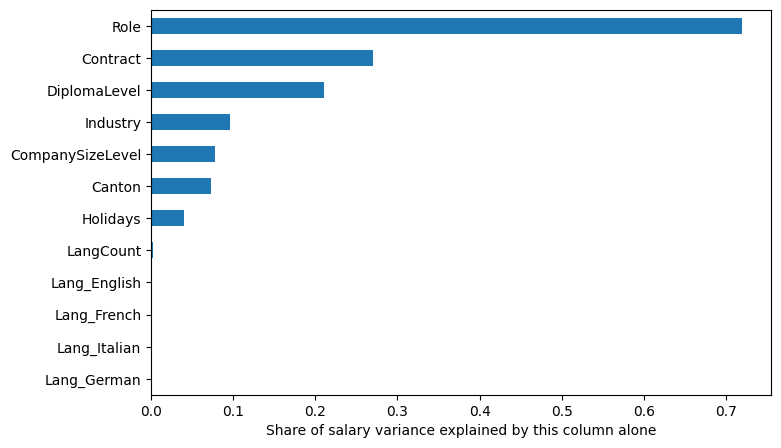

In [634]:


corr = data.select_dtypes("number").corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            annot_kws={"size": 8}, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation matrix (numeric columns)", loc="left")
plt.tight_layout()
plt.show()


y = data["SalaryCHF"]
cols = data.columns.drop("SalaryCHF")

#R^2 formula
share = lambda c: 1 - (y-y.groupby(c).transform("mean")).pow(2).sum() / (y - y.mean()).pow(2).sum()
scores = data[cols].apply(share).sort_values()

scores.plot.barh(figsize=(8, 5))
plt.xlabel("Share of salary variance explained by this column alone")
plt.show()


In [635]:
"""
from sklearn.compose import ColumnTransformer
print(data.isna().sum().sum()) # no more NaN value
print(data.dtypes)
print(data.groupby("Canton")["SalaryCHF"].agg(["mean", "count"]).sort_values("mean"))
X = data.drop(columns=["SalaryCHF"])
#x = np.array(data['Canton']).reshape(-1, 1)
y = data["SalaryCHF"]
#y = np.array(data["Canton"]).reshape(-1,1)

cat_cols = X.select_dtypes("object").columns.tolist()
num_cols = X.select_dtypes("number").columns.tolist()

print(cat_cols)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)])

model = Pipeline([
    ("prep", preprocess),
    ("reg", LinearRegression()),
])

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
scores = cross_val_score(model, X, y, cv=5, scoring="r2")
"""


'\nfrom sklearn.compose import ColumnTransformer\nprint(data.isna().sum().sum()) # no more NaN value\nprint(data.dtypes)\nprint(data.groupby("Canton")["SalaryCHF"].agg(["mean", "count"]).sort_values("mean"))\nX = data.drop(columns=["SalaryCHF"])\n#x = np.array(data[\'Canton\']).reshape(-1, 1)\ny = data["SalaryCHF"]\n#y = np.array(data["Canton"]).reshape(-1,1)\n\ncat_cols = X.select_dtypes("object").columns.tolist()\nnum_cols = X.select_dtypes("number").columns.tolist()\n\nprint(cat_cols)\n\npreprocess = ColumnTransformer([\n    ("num", StandardScaler(), num_cols),\n    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)])\n\nmodel = Pipeline([\n    ("prep", preprocess),\n    ("reg", LinearRegression()),\n])\n\nX_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)\nmodel.fit(X_train, y_train)\ny_pred = model.predict(X_test)\nscores = cross_val_score(model, X, y, cv=5, scoring="r2")\n'

In [636]:
counts = data["Canton"].value_counts()
rare = counts[counts < 10].index
print(f"{len(rare)} cCANTONS PUT TOGETHER, THEY ARE TOO RARE", list(rare))
data["Canton"] = data["Canton"].where(~data["Canton"].isin(rare), "Other")
data

12 cCANTONS PUT TOGETHER, THEY ARE TOO RARE ['SZ', 'NE', 'ZG', 'GR', 'SH', 'AR', 'NW', 'JU', 'OW', 'UR', 'AI', 'GL']


,Role,Contract,Industry,Canton,Holidays,SalaryCHF,Lang_French,Lang_German,Lang_English,Lang_Italian,LangCount,DiplomaLevel,CompanySizeLevel
0,Manager,Permanent,Education,ZH,25,314500.0,0,1,1,0,2,4,1
1,Senior,Permanent,Manufacturing,SO,25,143600.0,1,1,0,0,2,2,3
2,Mid-level,Permanent,Manufacturing,SO,25,84300.0,0,1,1,0,2,2,2
3,Junior,1 year,Healthcare,BE,25,50333.0,0,1,1,0,2,2,1
4,Mid-level,Permanent,Finance,FR,26,144667.0,1,1,0,0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Intern,6 months,Hospitality,SO,28,41667.0,1,1,1,0,3,3,0
496,Junior,Permanent,Finance,ZH,25,84500.0,1,1,0,0,2,1,2
497,Senior,Permanent,Manufacturing,TG,24,152750.0,0,1,0,0,1,2,3
498,Mid-level,2 years,Consulting,ZH,28,114444.0,0,1,0,0,1,2,2


In [637]:

#print(data.isna().sum().sum()) # no more NaN value
#print(data.dtypes)
#print(data.groupby("Canton")["SalaryCHF"].agg(["mean", "count"]).sort_values("mean"))
from sklearn import linear_model
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LassoCV


X = data.drop(columns=["SalaryCHF"])
#x = np.array(data['Canton']).reshape(-1, 1)
y = data["SalaryCHF"]
#y = np.array(data["Canton"]).reshape(-1,1)

cat_cols = X.select_dtypes("object").columns.tolist()
num_cols = X.select_dtypes("number").columns.tolist()

#print(cat_cols)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)])

linear = TransformedTargetRegressor(
    regressor=LinearRegression()
)

linear_log = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log,
    inverse_func=np.exp,
)

gradient_boosting = TransformedTargetRegressor(
    regressor=GradientBoostingRegressor(),
    #func=np.log,
    #inverse_func=np.exp
)

lasso = TransformedTargetRegressor(
    regressor=LassoCV(max_iter=50000, random_state=0),
    func=np.log,
    inverse_func=np.exp,
)

model = Pipeline([
    ("prep", preprocess),
    ("reg", linear),
])

model_log = Pipeline([
    ("prep", preprocess),
    ("reg", linear_log),
])

model_gb = Pipeline([
    ("prep", preprocess),
    ("reg", gradient_boosting),
])

model_lasso = Pipeline([
    ("prep", preprocess),
    ("reg", lasso),
])

SEED = 42

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=SEED)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
scores_reg_wo_log = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2")

model_log.fit(X_train, y_train)
y_pred_log = model_log.predict(X_test)
scores_reg_w_log = cross_val_score(model_log, X_train, y_train, cv=cv, scoring="r2")

model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
scores_grad_boost = cross_val_score(model_gb, X_train, y_train, cv=cv, scoring="r2")

model_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_test)
scores_lasso = cross_val_score(model_lasso, X_train, y_train, cv=cv, scoring="r2")

result = {}
abreviations = ["reg_wo_log", "reg_w_log", "grad_boost", "lasso"]

print(f"Mean scores (without log): {np.mean(scores_reg_wo_log)}")
print(f"Mean scores (with log): {np.mean(scores_reg_w_log)}")
print(f"Mean scores (with gradient boosting): {np.mean(scores_grad_boost)}")
print(f"Mean scores (with lasso): {np.mean(scores_lasso)}")



Mean scores (without log): 0.8803072475503957
Mean scores (with log): 0.9778823378282807
Mean scores (with gradient boosting): 0.8723056141110398
Mean scores (with lasso): 0.9602284191866204


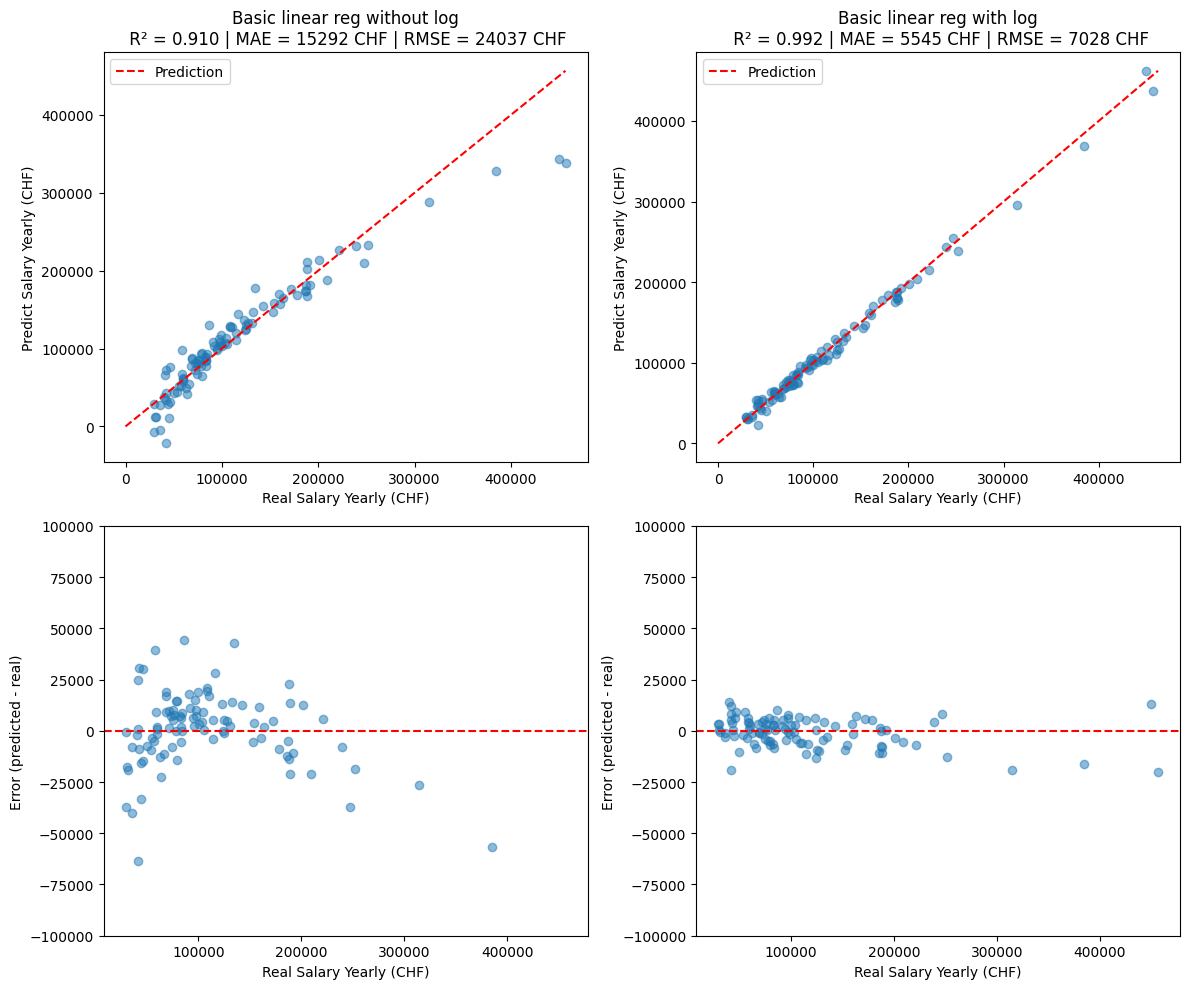

In [638]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error



#REMINDER : R^2 = 1 - (sum((y_test - y_pred) ** 2) / sum((y_test - np.mean(y_test)) ** 2)) -> 0.75 means the model removes 75% of the squared error we get 
# by just predicting the mean (in CHF the error only drops by 1 - sqrt(0.25) = 50%).

#MAE = Mean absolute error -> 
#RMSE = Root mean squared error -> 

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (pred, nom, abreviation) in enumerate([(y_pred, "Basic linear reg without log", abreviations[0]), (y_pred_log, "Basic linear reg with log", abreviations[1])]):
    ax = axes[0, i]
    ax.scatter(y_test, pred, alpha=0.5)
    lims = [0, max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--", label="Prediction")
    ax.set_xlabel("Real Salary Yearly (CHF)")
    ax.set_ylabel("Predict Salary Yearly (CHF)")
    result[abreviation] = {
        "MeanScore" : np.mean(eval(f"scores_{abreviation}")),
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": int(np.sqrt(mean_squared_error(y_test, pred)))
    }
    ax.set_title(f"{nom}\n R² = {result[abreviation]["R2"]:.3f} | MAE = {result[abreviation]["MAE"]:.0f} CHF | RMSE = {int(result[abreviation]["RMSE"])} CHF")
    ax.legend()

    ax = axes[1, i]
    ax.scatter(y_test, pred - y_test, alpha=0.5)
    ax.set_ylim(-100000, 100000)
    ax.axhline(0, color="r", linestyle="--")
    ax.set_xlabel("Real Salary Yearly (CHF)")
    ax.set_ylabel("Error (predicted - real)")

plt.tight_layout()
plt.show()

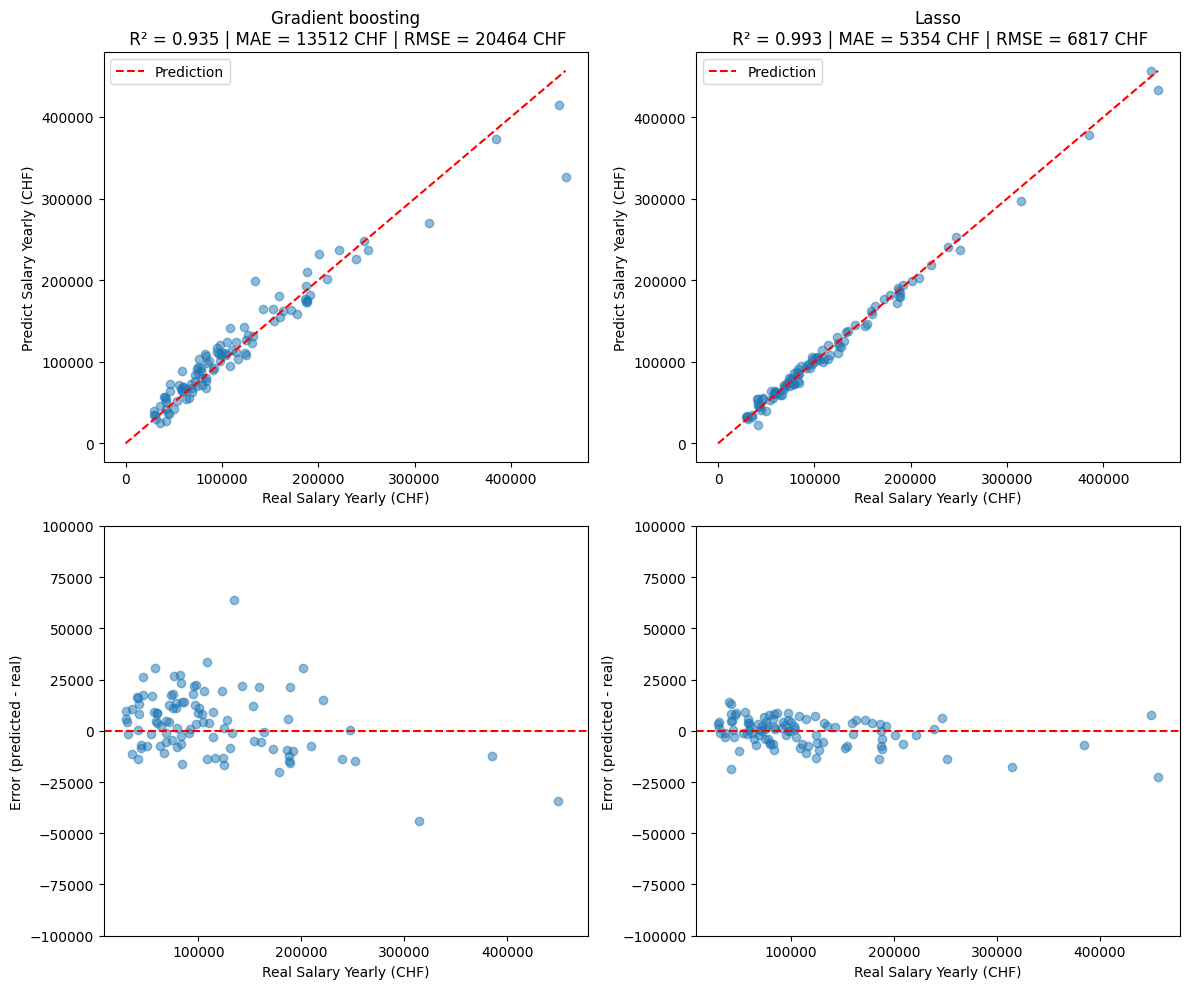

In [639]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (pred, nom, abreviation) in enumerate([(y_pred_gb, "Gradient boosting", abreviations[2]), (y_pred_lasso, "Lasso", abreviations[3])]):
    ax = axes[0, i]
    ax.scatter(y_test, pred, alpha=0.5)
    lims = [0, max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--", label="Prediction")
    ax.set_xlabel("Real Salary Yearly (CHF)")
    ax.set_ylabel("Predict Salary Yearly (CHF)")
    result[abreviation] = {
        "MeanScore" : np.mean(eval(f"scores_{abreviation}")),
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": int(np.sqrt(mean_squared_error(y_test, pred)))
    }
    ax.set_title(f"{nom}\n R² = {result[abreviation]["R2"]:.3f} | MAE = {result[abreviation]["MAE"]:.0f} CHF | RMSE = {int(result[abreviation]["RMSE"])} CHF")
    ax.legend()

    ax = axes[1, i]
    ax.scatter(y_test, pred - y_test, alpha=0.5)
    ax.set_ylim(-100000, 100000)
    ax.axhline(0, color="r", linestyle="--")
    ax.set_xlabel("Real Salary Yearly (CHF)")
    ax.set_ylabel("Error (predicted - real)")

plt.tight_layout()
plt.show()

In [640]:
result_df = pd.DataFrame(result).T
result_df

,MeanScore,R2,MAE,RMSE
reg_wo_log,0.880307,0.909980,15291.720923,24037.0
reg_w_log,0.977882,0.992303,5545.187586,7028.0
grad_boost,0.872306,0.934752,13511.682758,20464.0
lasso,0.960228,0.992758,5354.324556,6817.0


In [641]:
noms = model_log.named_steps["prep"].get_feature_names_out()
coefs = model_log.named_steps["reg"].regressor_.coef_

coef_df = pd.DataFrame({"feature": noms, "coef": coefs})
coef_df["effet_%"] = (np.exp(coef_df["coef"]) - 1) * 100
coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index).round(2)

,feature,coef,effet_%
8,cat__Role_Intern,-1.98,-86.16
9,cat__Role_Junior,-1.58,-79.36
12,cat__Role_Mid-level,-1.23,-70.66
13,cat__Role_Senior,-0.89,-58.79
10,cat__Role_Lead,-0.58,-44.21
25,cat__Industry_Pharma,0.38,45.75
20,cat__Industry_Finance,0.35,42.35
23,cat__Industry_IT,0.30,34.93
11,cat__Role_Manager,-0.27,-23.84
17,cat__Industry_Consulting,0.26,29.29


In [ ]:
import json

p = model_log.named_steps["prep"]
r = model_log.named_steps["reg"].regressor_
sc = p.named_transformers_["num"]
enc = p.named_transformers_["cat"]

export = {
    "intercept": float(r.intercept_),
    "numeric": {n: {"mean": float(m), "std": float(s), "coef": float(c)}
                for n, m, s, c in zip(num_cols, sc.mean_, sc.scale_, r.coef_[:len(num_cols)])},
    "categorical": {},
}

i = len(num_cols)
for col, cats in zip(cat_cols, enc.categories_):
    export["categorical"][col] = {"__reference__": cats[0]}
    for c in cats[1:]:
        export["categorical"][col][str(c)] = float(r.coef_[i])
        i += 1

with open("salary_model.json", "w") as f:
    json.dump(export, f, indent=2, ensure_ascii=False)

print(f"{i} export coeff")

42 export coeff
